# Plots to check the output of a multi-zone model

In [346]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, BoundaryNorm
from matplotlib.ticker import MultipleLocator
import vice

from multizone_stars import MultizoneStars
from plotting import insert_colorbar_axes
from utils import radial_gradient, get_bin_centers, vice_to_mwm_col
from stats import weighted_quantile
from contours import plot_kde2D_contours
import paths
from multizone._globals import MAX_SF_RADIUS, ZONE_WIDTH, END_TIME

plt.style.use(paths.styles / 'notebook.mplstyle')

In [347]:
OUTPUT_NAME = 'yZ2-cristallo11-x2-mscale/diskmodel'

GALR_BINS = [3, 5, 7, 9, 11, 13]
ABSZ_BINS = [0, 0.5, 1, 2]

mzs = MultizoneStars.from_output(OUTPUT_NAME)

In [348]:
# Make folder in src/extra to store plots
output_dir = paths.extra / 'multizone' / OUTPUT_NAME.replace('diskmodel', '')
if not output_dir.exists():
    output_dir.mkdir(parents=True)

In [349]:
# Import MWM data
mwm = pd.read_csv(paths.data / 'MWM' / 'sample.csv')
mwm

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,ecc,z_max,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr
0,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,0.152711,0.196782,8.590056,0.0,-0.263113,0.010890,-0.013271,0.013271,0.260731,0.274003
1,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,0.046648,0.106835,9.153462,0.0,-0.241018,0.079030,0.003839,-0.003839,0.323887,0.320048
2,54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,...,0.124409,0.486441,10.254416,0.0,-0.112523,0.228345,-0.020530,0.020530,0.320339,0.340869
3,54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,...,0.085229,0.177560,9.035937,0.0,0.061913,0.190950,0.048523,-0.048523,0.177560,0.129037
4,54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,...,0.136714,1.574658,14.852359,0.0,-0.182748,0.012715,0.005658,-0.005658,0.201122,0.195464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121317,129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,...,0.076767,0.010929,7.758100,0.0,-0.059793,0.246831,0.047802,-0.047802,0.354426,0.306624
121318,129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,...,0.053491,0.931364,10.770966,0.0,-0.523929,-0.496442,-0.060767,0.060767,-0.033280,0.027487
121319,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,0.442343,0.031859,4.912325,0.0,-0.363648,-0.118817,-0.011611,0.011611,0.233220,0.244831
121320,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,0.132427,0.561359,9.945469,0.0,-0.176592,0.063355,-0.014382,0.014382,0.225565,0.239947


## Science Plots

In [350]:
def plot_gas_abundance(ax, mzs, xcol, ycol, radius=None, label='', **kwargs):
    """
    Plot the ISM abundance tracks for the mean zone.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes on which to plot the gas abundance.
    mzs : MultizoneStars object
        Object containing model stars data. Gas abundance will be plotted from
        the mean radius of the data.
    xcol : str
        Column of data to plot on the x-axis.
    ycol : str
        Column of data to plot on the y-axis.
    label : str, optional
        Line label. The default is ''.
    **kwargs passed to matplotlib.pyplot.plot()

    Returns
    -------
    lines : list of Line2D
        Output of Axes.plot().
    """
    if radius is None:
        radius = 0.5 * (mzs.galr_lim[0] + mzs.galr_lim[1])
    zone = int(radius / mzs.zone_width)
    zone_path = str(mzs.fullpath / ('zone%d' % zone))
    hist = vice.history(zone_path)
    lines = ax.plot(hist[xcol], hist[ycol], label=label, **kwargs)
    return lines


def hayden_plot(
        mzs, 
        xcol, ycol, 
        xlim=None, ylim=None, 
        color_by='galr_origin', 
        clim=None,
        cmap='viridis_r'
    ):
    """
    Plot a grid of panels defined by Rgal and |z|, as in Hayden et al. (2015).
    """
    # Set up plot
    rows = len(ABSZ_BINS) - 1
    cols = len(GALR_BINS) - 1
    width = 8
    fig, axs = plt.subplots(
        rows, cols, 
        figsize=(width, 0.9*(width/cols)*rows),
        sharex=True, sharey=True,
        gridspec_kw={'hspace': 0., 'wspace': 0.}
    )
    # Colorbar
    cax = insert_colorbar_axes(fig, pad=0.03)
    if clim is None:
        clim = (mzs(color_by).min(), mzs(color_by).max())
    cbar = fig.colorbar(
        ScalarMappable(
            Normalize(vmin=clim[0], vmax=clim[1]), 
            plt.get_cmap(cmap)
        ), 
        cax, 
        label=color_by
    )
    # Plot multizone output
    for i, row in enumerate(axs):
        absz_lim = (ABSZ_BINS[-(i+2)], ABSZ_BINS[-(i+1)])
        for j, ax in enumerate(row):
            galr_lim = (GALR_BINS[j], GALR_BINS[j+1])
            subset = mzs.region(galr_lim, absz_lim)
            subset.scatter_plot(ax, xcol, ycol, color=color_by,
                                cmap=cbar.cmap, norm=cbar.norm)
            if xcol == 'age':
                xcol_gas = 'lookback'
            else:
                xcol_gas = xcol
            plot_gas_abundance(ax, subset, xcol_gas, ycol, c='k')
            # Plot MWM data contours
            mwm_subset = mwm[
                (mwm['Rg'] >= galr_lim[0]) &
                (mwm['Rg'] < galr_lim[1]) &
                (mwm['z_max'] >= absz_lim[0]) &
                (mwm['z_max'] < absz_lim[1])
            ]
            if xcol != 'age':
                plot_kde2D_contours(ax, mwm_subset, vice_to_mwm_col(xcol), vice_to_mwm_col(ycol))
    # Format axes
    axs[0,0].set_xlim(xlim)
    axs[0,0].set_ylim(ylim)
    for j, ax in enumerate(axs[0]):
        galr_lim = (GALR_BINS[j], GALR_BINS[j+1])
        ax.set_title('R=%s-%s kpc' % galr_lim)
    for i, ax in enumerate(axs[:,-1]):
        absz_lim = (ABSZ_BINS[-(i+2)], ABSZ_BINS[-(i+1)])
        ax.yaxis.set_label_position('right')
        ax.set_ylabel('|z|=%s-%s kpc' % absz_lim)
    for ax in axs[-1]:
        ax.set_xlabel(xcol)
    for ax in axs[:,0]:
        ax.set_ylabel(ycol)
    fig.suptitle(OUTPUT_NAME)
    fname = '%s_%s_grid.png' % (
        xcol.replace('[', '').replace('/', '').replace(']', ''),
        ycol.replace('[', '').replace('/', '').replace(']', ''),
    )
    plt.savefig(output_dir / fname)
    plt.show()
    

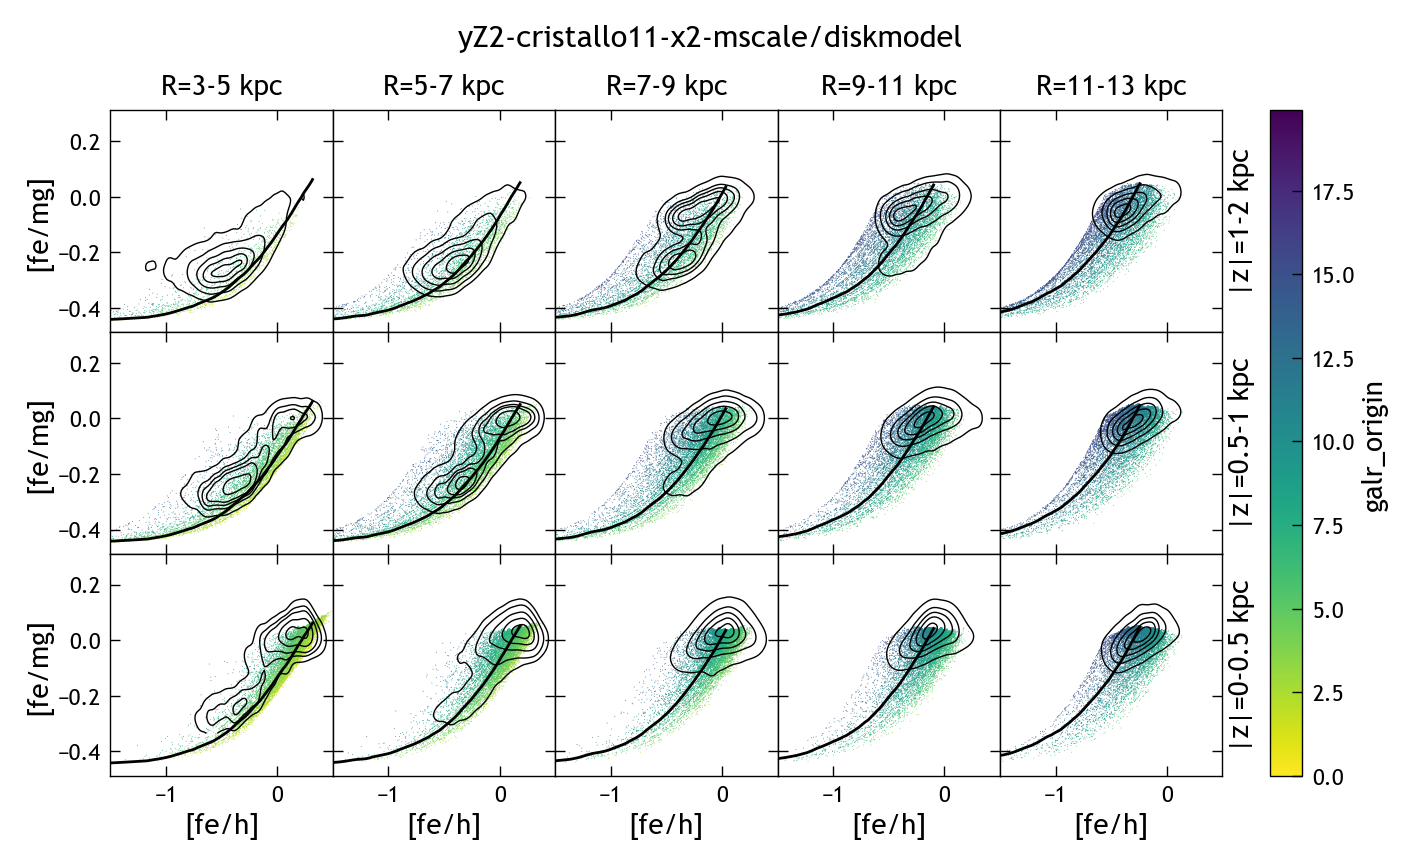

In [351]:
hayden_plot(mzs, '[fe/h]', '[fe/mg]', xlim=(-1.5, 0.5))

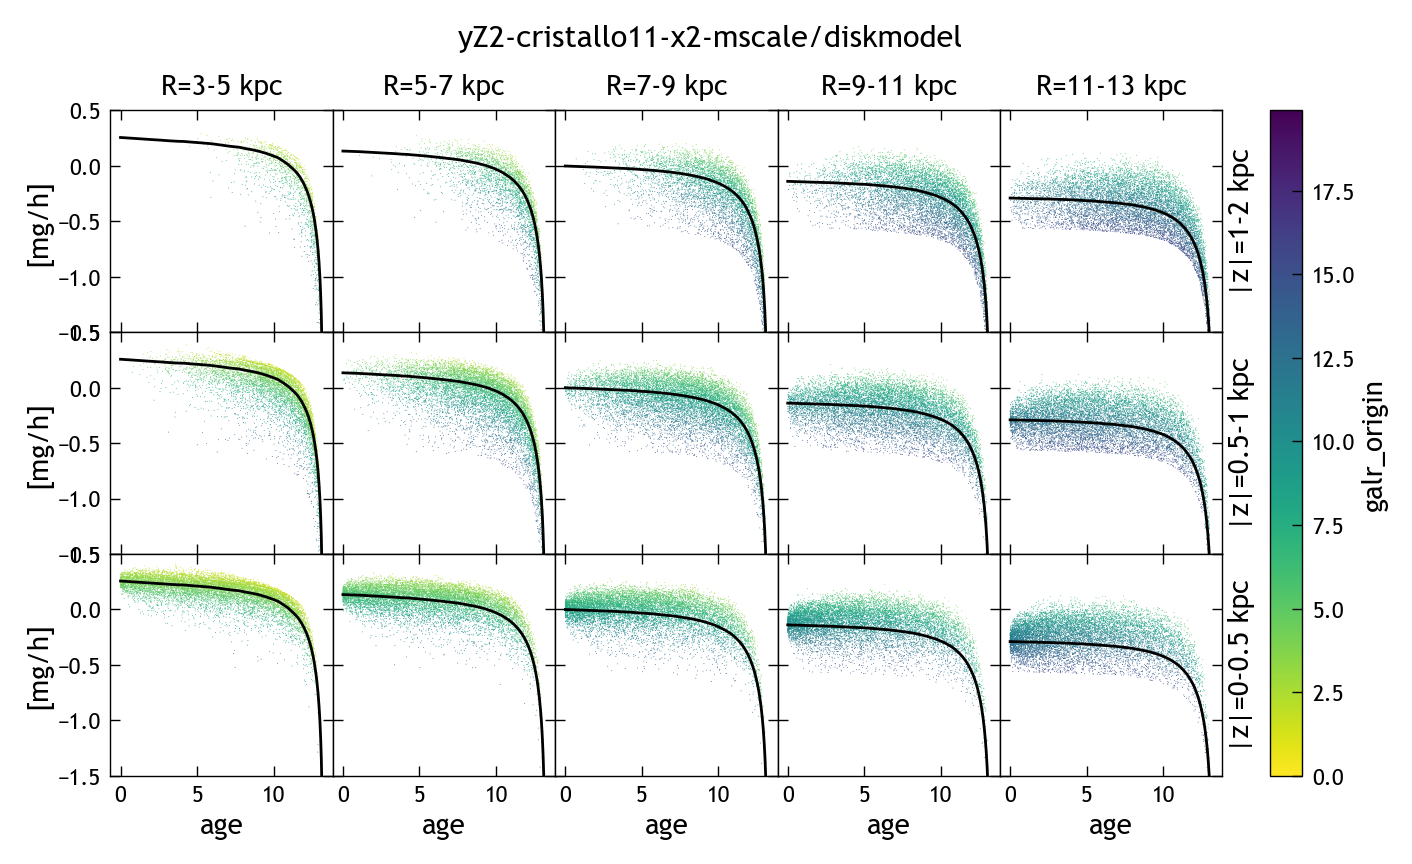

In [352]:
hayden_plot(mzs, 'age', '[mg/h]', ylim=(-1.5, 0.5))

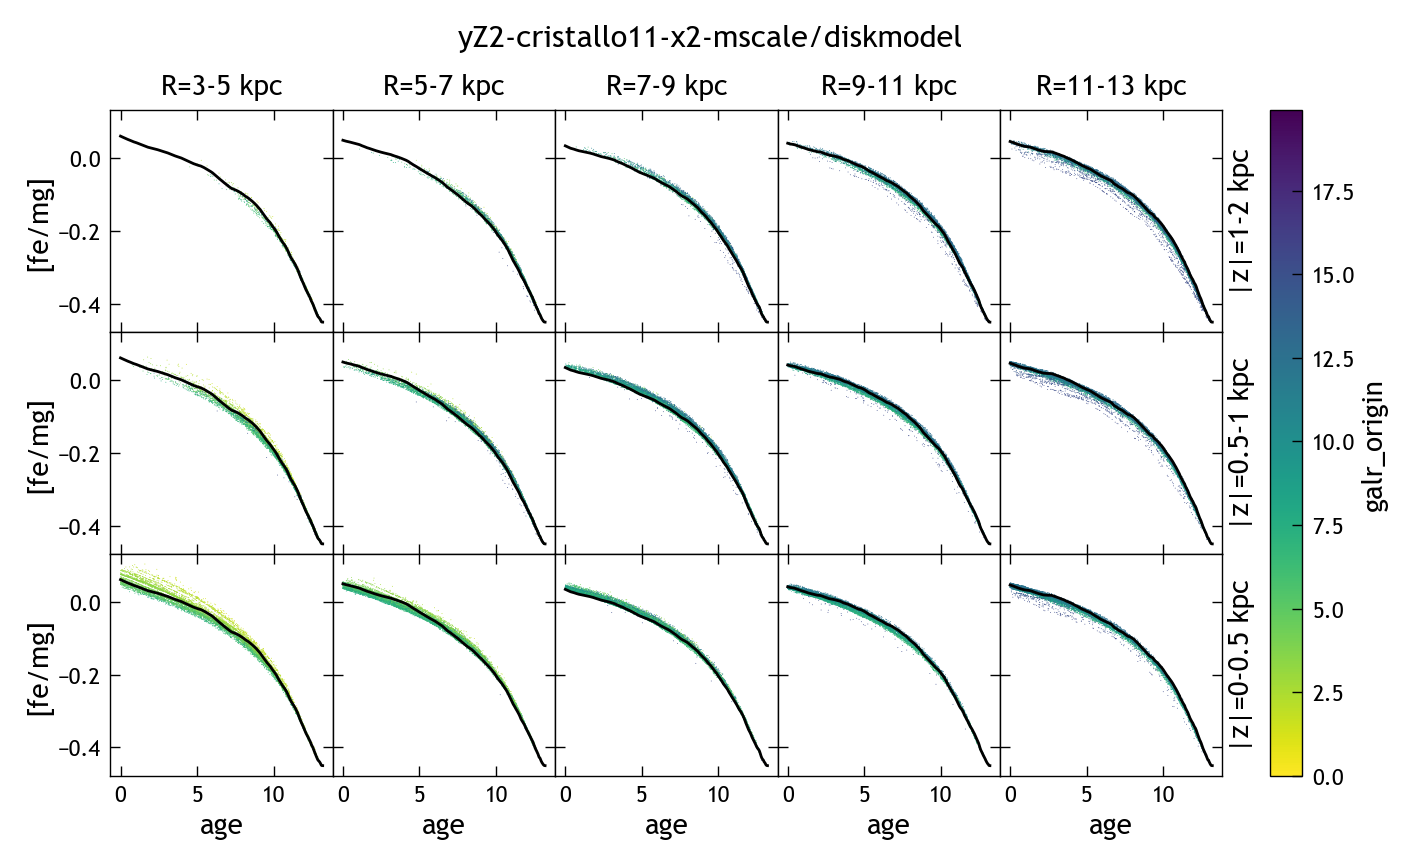

In [353]:
hayden_plot(mzs, 'age', '[fe/mg]')

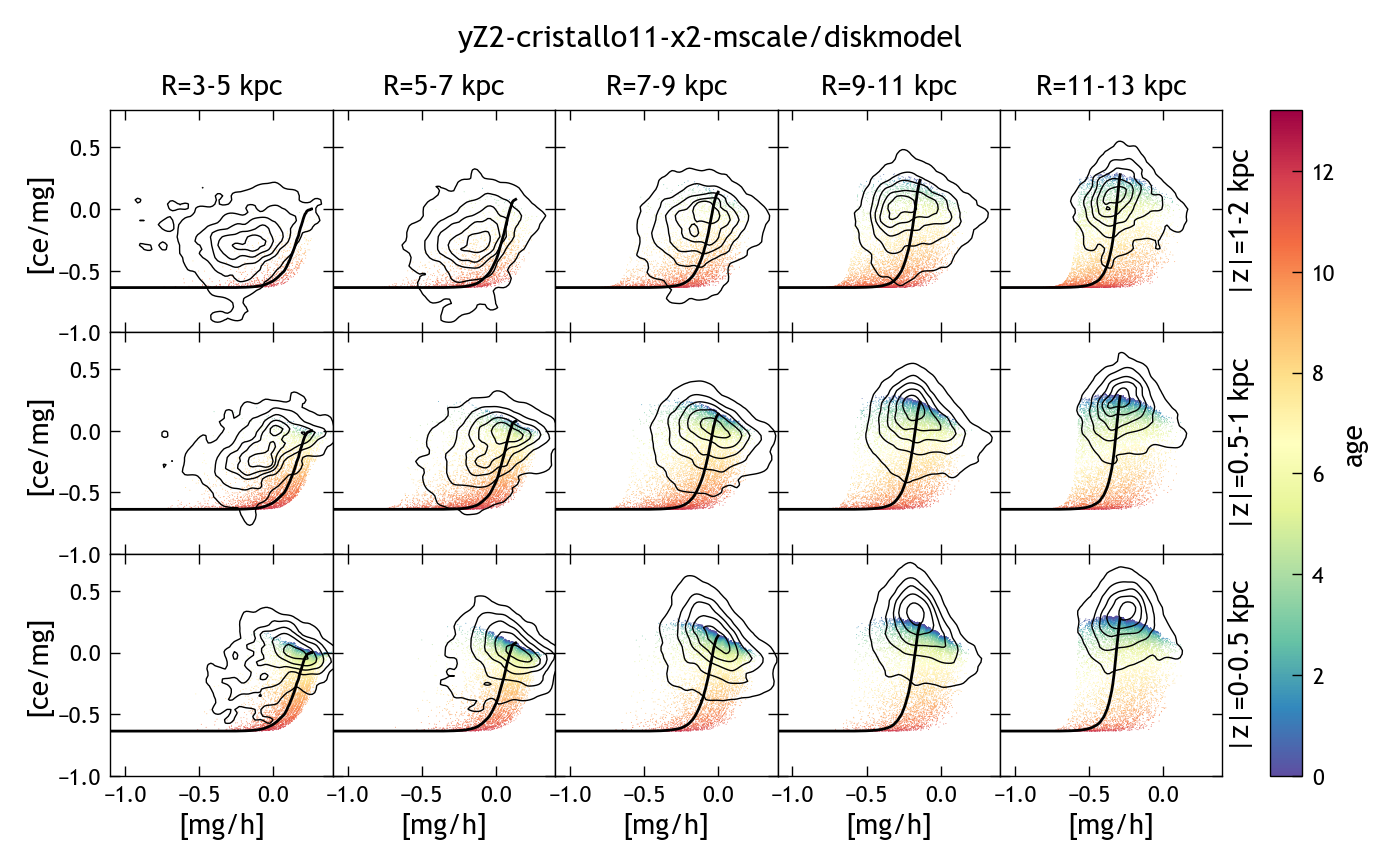

In [354]:
hayden_plot(mzs, '[mg/h]', '[ce/mg]', xlim=(-1.1, 0.4), ylim=(-1, 0.8), color_by='age', cmap='Spectral_r')

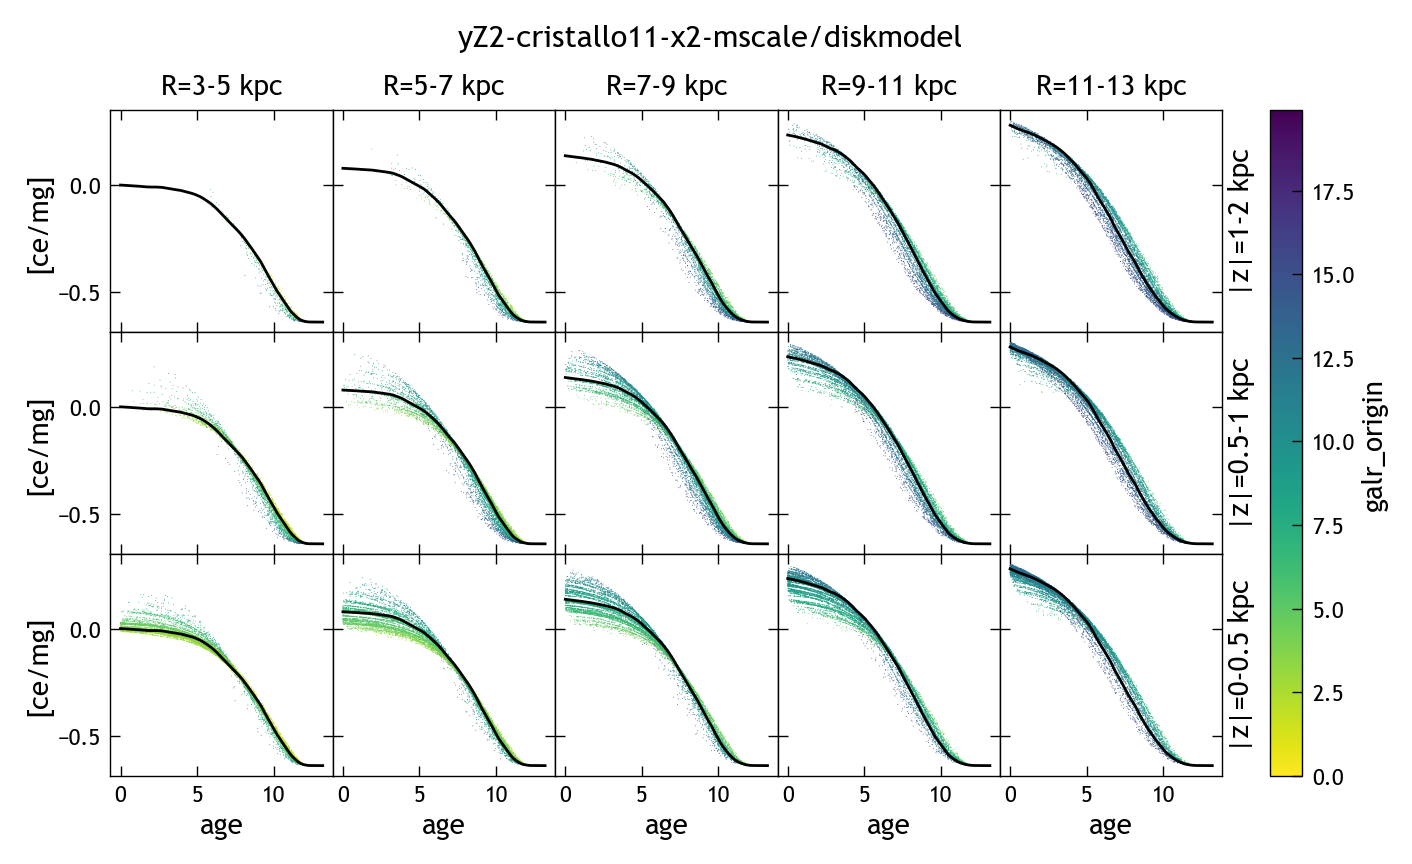

In [355]:
hayden_plot(mzs, 'age', '[ce/mg]')

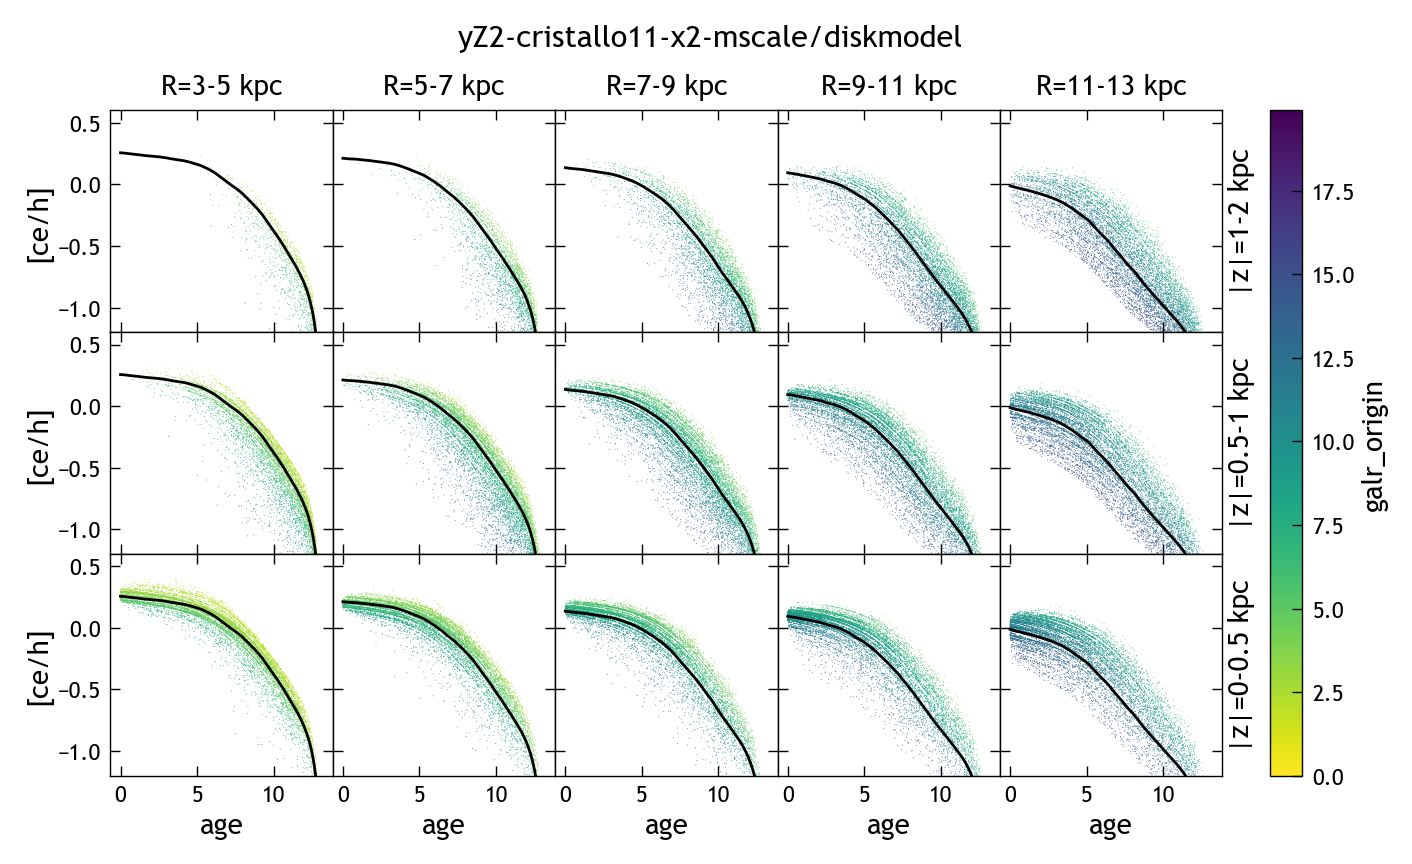

In [356]:
hayden_plot(mzs, 'age', '[ce/h]', ylim=(-1.2, 0.6))

In [357]:
def compare_zone_evolution(mzs, col, cmap='viridis_r', absz_lim=(0, 0.5)):
    fig, ax = plt.subplots(figsize=(4, 3))
    radii = [4, 6, 8, 10, 12]
    cmap = plt.get_cmap(cmap)
    norm = Normalize(vmin=radii[0], vmax=radii[-1])
    for r in [4, 6, 8, 10, 12]:
        plot_gas_abundance(
            ax, mzs, 'lookback', col, 
            radius=r, color=cmap(norm(r)), label='%s kpc' % r
        )
    mwm_ages = mwm[mwm['use_age']]
    plot_kde2D_contours(ax, mwm_ages, 'age', vice_to_mwm_col(col))
    ax.set_xlabel('age')
    ax.set_ylabel(col)
    ax.set_xlim((0, END_TIME))
    ax.set_ylim((-0.8, 0.8))
    ax.legend()
    fig.suptitle(OUTPUT_NAME)
    fname = '%s_zone_evolution.png' % (
        col.replace('[', '').replace('/', '').replace(']', ''),
    )
    plt.savefig(output_dir / fname)
    plt.show()

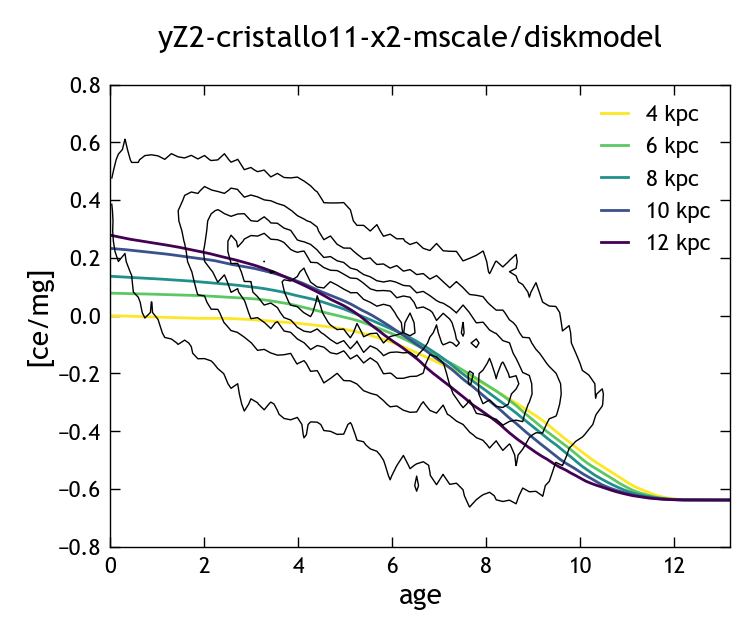

In [358]:
compare_zone_evolution(mzs, '[ce/mg]')

In [359]:
def mdf_plot(mzs, abund, absz_lim=(0, 0.5), cmap='viridis_r', xlim=None, smoothing=0.05):
    fig, ax = plt.subplots(figsize=(4, 3))
    galr_bin_centers = get_bin_centers(GALR_BINS)
    cmap = plt.get_cmap(cmap)
    norm = BoundaryNorm(GALR_BINS, cmap.N)
    colors = cmap(norm(galr_bin_centers))
    for j in range(len(GALR_BINS)-1):
        galr_lim = GALR_BINS[j:j+2]
        subset = mzs.region(galr_lim, absz_lim)
        mdf, bin_edges = subset.mdf(abund, bins=100, range=xlim, smoothing=smoothing)
        ax.plot(get_bin_centers(bin_edges), mdf, color=colors[j])
    ax.set_xlabel(abund)
    ax.set_ylabel('PDF')
    fig.colorbar(ScalarMappable(norm, cmap), ax=ax, label='Rgal [kpc]')
    fig.suptitle(OUTPUT_NAME)
    fname = '%s_mdf.png' % abund.replace('[', '').replace('/', '').replace(']', '')
    fig.savefig(output_dir / fname)
    plt.show()
    

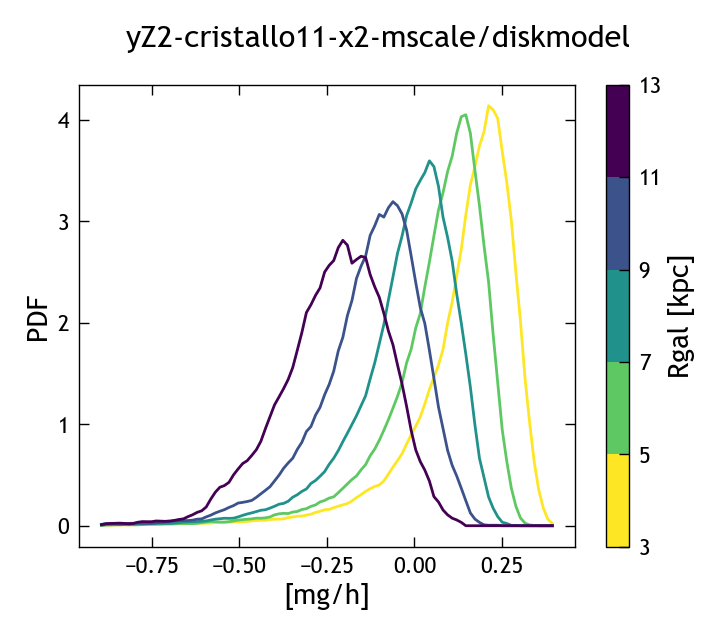

In [360]:
mdf_plot(mzs, '[mg/h]', xlim=(-0.9, 0.4))

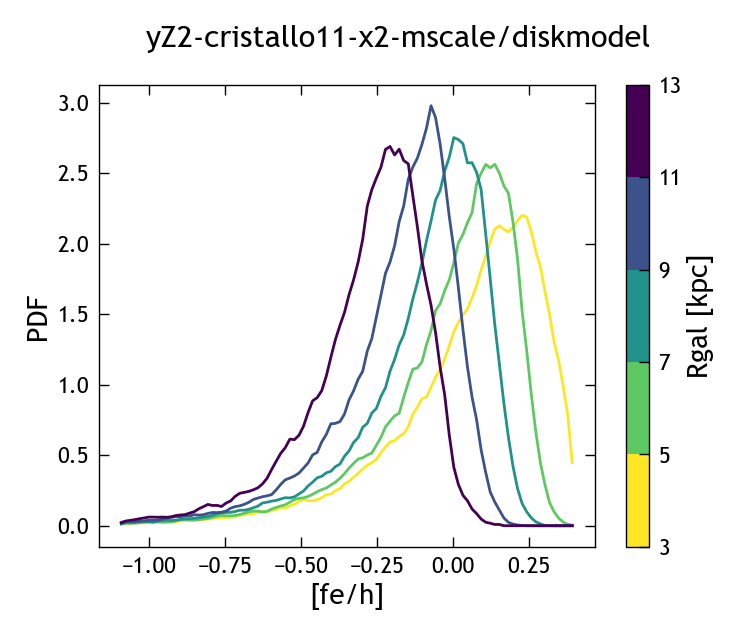

In [361]:
mdf_plot(mzs, '[fe/h]', xlim=(-1.1, 0.4))

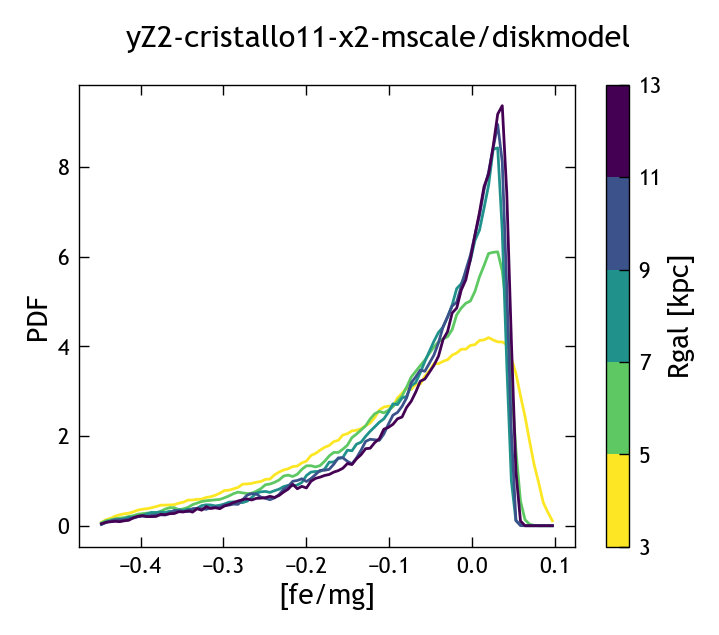

In [362]:
mdf_plot(mzs, '[fe/mg]', xlim=(-0.45, 0.1), smoothing=0.02)

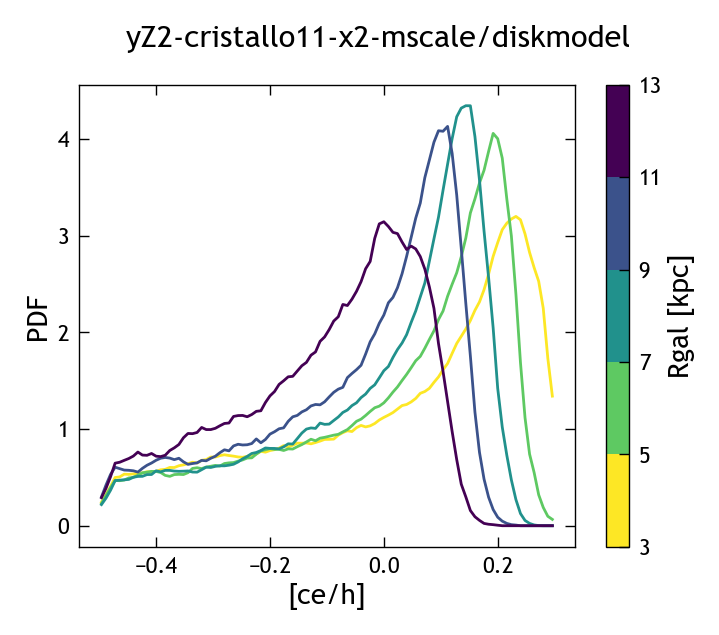

In [363]:
mdf_plot(mzs, '[ce/h]', xlim=(-0.5, 0.3))

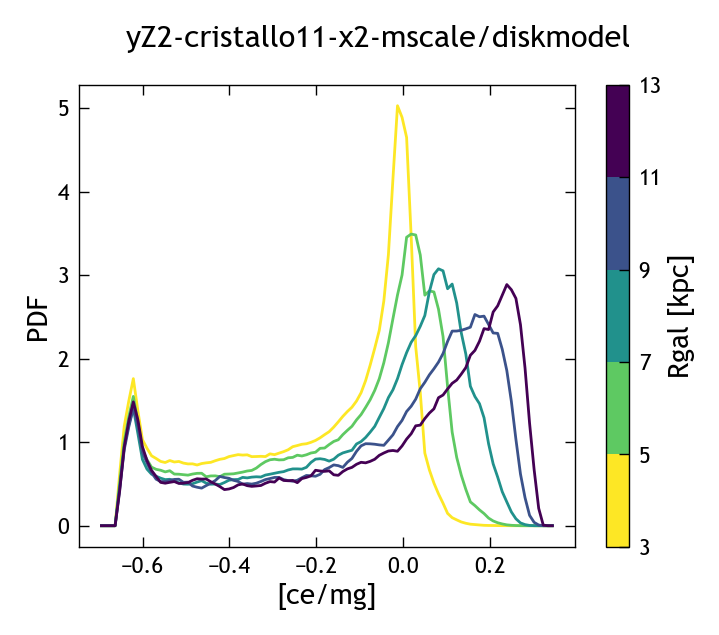

In [364]:
mdf_plot(mzs, '[ce/mg]', xlim=(-0.7, 0.35), smoothing=0.05)

## Sanity Checks

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/outputs/output.py:131: UserWarning: agb ce yield not encoded with output. Assuming the current yield setting, which may not reflect the yield setting at the time the simulation was ran.
  self.__c_version = c_output(name)


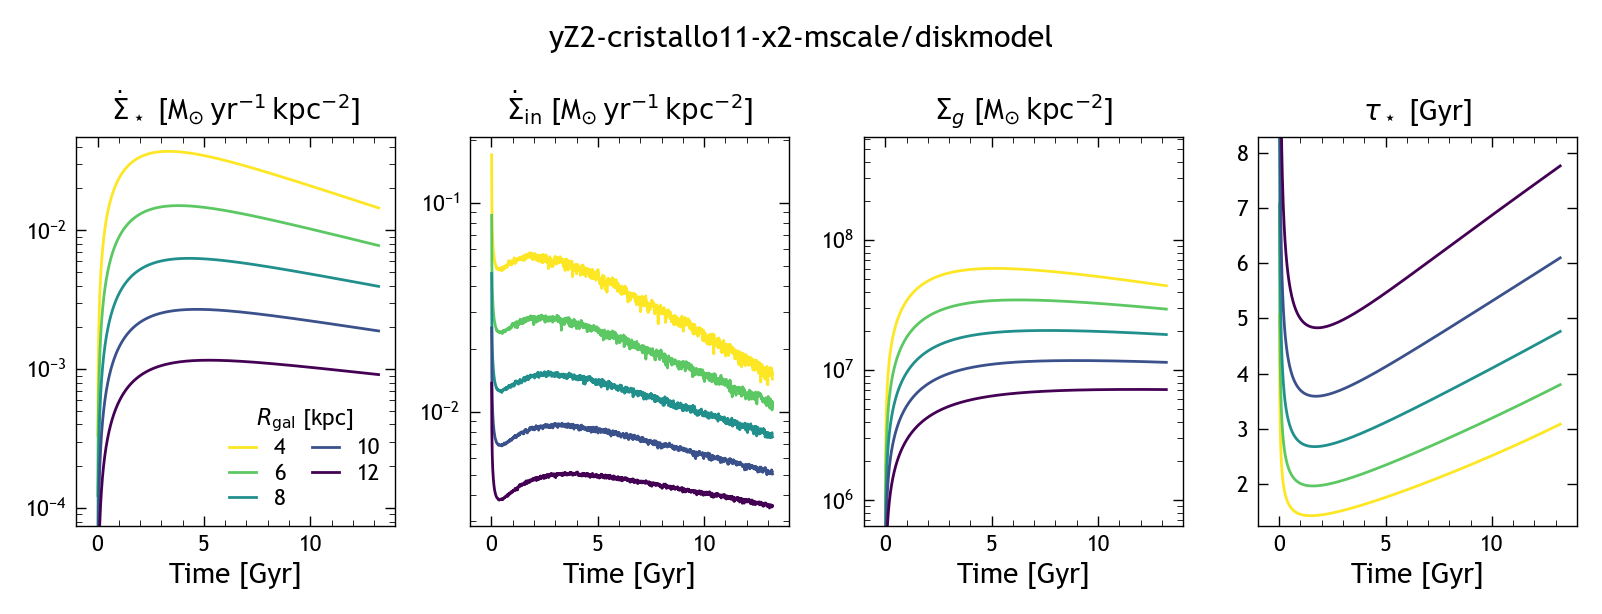

In [365]:
# Plot the star formation history
fig, axs = plt.subplots(
    1, 4, 
    sharex=True, 
    tight_layout=True,
    figsize=(8, 3)
)
multioutput = vice.output(str(paths.multizone / OUTPUT_NAME))
axs[0].set_title(r'$\dot \Sigma_\star$ [M$_{\odot}\,\rm{yr}^{-1}\,\rm{kpc}^{-2}$]')
axs[0].set_yscale('log')
axs[1].set_title(r'$\dot \Sigma_{\rm in}$ [M$_{\odot}\,\rm{yr}^{-1}\,\rm{kpc}^{-2}$]')
axs[1].set_yscale('log')
axs[2].set_title(r'$\Sigma_g$ [M$_{\odot}\,\rm{kpc}^{-2}$]')
axs[2].set_yscale('log')
axs[3].set_title(r'$\tau_\star$ [Gyr]')
for ax in axs:
    ax.set_xlabel('Time [Gyr]')
    ax.set_xlim((-1, 14))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
zones = [int(galr / ZONE_WIDTH) for galr in get_bin_centers(GALR_BINS)]
cmap = plt.get_cmap('viridis_r')
norm = Normalize(vmin=zones[0], vmax=zones[-1])
linestyle = '-'
for zone in zones:
    color = cmap(norm(zone))
    radius = (zone + 0.5) * ZONE_WIDTH
    area = np.pi * ((radius + ZONE_WIDTH)**2 - radius**2)
    label = f'{zone * ZONE_WIDTH:.0f}'
    history = multioutput.zones[f'zone{zone}'].history
    time = np.array(history['time'])
    sf_surface = np.array(history['sfr']) / area
    axs[0].plot(time[1:], sf_surface[1:], color=color, ls=linestyle, label=label)
    axs[0].set_ylim((sf_surface[10], None))
    infall_surface = np.array(history['ifr']) / area
    axs[1].plot(time, infall_surface, color=color, label=label, ls=linestyle)
    gas_surface = np.array(history['mgas']) / area
    axs[2].plot(time, gas_surface, color=color, ls=linestyle, label=label)
    axs[2].set_ylim((gas_surface[10], None))
    tau_star = [history['mgas'][i+1] / history['sfr'][i+1] * 1e-9 for i in range(
                len(history['time']) - 1)]
    axs[3].plot(history['time'][1:], tau_star, color=color, ls=linestyle,
                label=label)
    axs[3].set_ylim((None, tau_star[10]))
axs[0].legend(frameon=False, title=r'$R_{\rm gal}$ [kpc]', ncols=2, 
                loc='lower right', borderpad=0.2, labelspacing=0.2, columnspacing=1.2)
fig.suptitle(OUTPUT_NAME)
fig.savefig(output_dir / 'sfh.png')
plt.show()

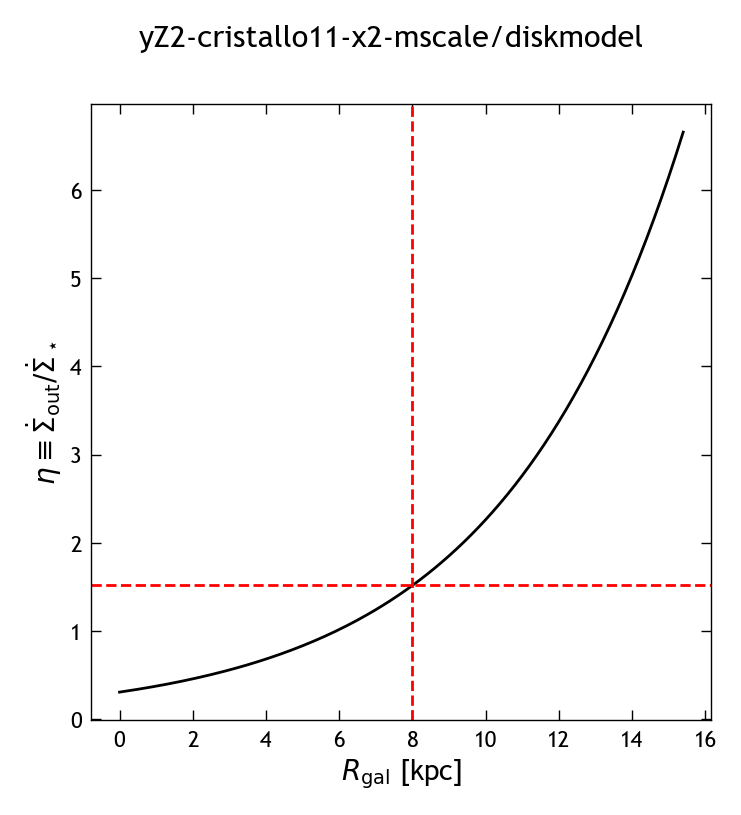

In [366]:
# Plot outflow mass-loading factor
fig, ax = plt.subplots()

multioutput = vice.output(str(paths.multizone / OUTPUT_NAME))
eta_list = radial_gradient(multioutput, 'eta_0')
radii = [i * ZONE_WIDTH for i in range(len(eta_list))]

ax.plot(radii, eta_list, 'k-')

ax.axvline(8, color='r', ls='--')
ax.axhline(eta_list[80], color='r', ls='--')

ax.set_xlabel(r'$R_{\rm gal}$ [kpc]')
ax.set_ylabel(r'$\eta\equiv\dot\Sigma_{\rm out}/\dot\Sigma_\star$')
fig.suptitle(OUTPUT_NAME)
fig.savefig(output_dir / 'outflows.png')
plt.show()

In [367]:
def stellar_density_gradient(mzs, rbins, origin=False):
    """
    Calculate the stellar surface mass density gradient for the given VICE
    multi-zone model output.
    
    Parameters
    ----------
    mzs : MultizoneStars
    rbins : array
    origin : bool, optional
        If True, sort stars by birth radius instead of final. Default is False.
    
    Returns
    -------
    numpy.ndarray
        Stellar surface mass densities in each radius bin [Msun kpc^-2].
    
    """
    stars = mzs.stars.copy()
    if origin:
        rcol = 'galr_origin'
    else:
        rcol = 'galr_final'
    masses = stars.groupby(pd.cut(stars[rcol], rbins), 
                           observed=False)['mstar'].sum()
    areas = [np.pi * (rbins[i+1]**2 - rbins[i]**2) for i in range(len(rbins)-1)]
    return masses / np.array(areas)


def gas_density_gradient(name, zone_width=ZONE_WIDTH, index=-1):
    """
    Calculate the radial gas surface density gradient.
    
    Parameters
    ----------
    name : str
        Relative path to multizone output directory.
    rbins : array-like, optional
        Radial bins.
    index : int, optional
        Time-index to calculate the radial gradient at.
    
    Returns
    -------
    sigma_gas : numpy.ndarray
        Gas surface densities in each radius bin [Msun kpc^-2]
    radii : numpy.ndarray
        Inner radii of zones in kpc.
    
    """
    multioutput = vice.output(str(paths.multizone / name))
    gas_mass_gradient = radial_gradient(multioutput, 'mgas', 
                                        zone_width=zone_width, index=index)
    radii = [i * zone_width for i in range(len(gas_mass_gradient))]
    areas = [np.pi * ((r + zone_width)**2 - r**2) for r in radii]
    return np.array(gas_mass_gradient) / np.array(areas), np.array(radii)

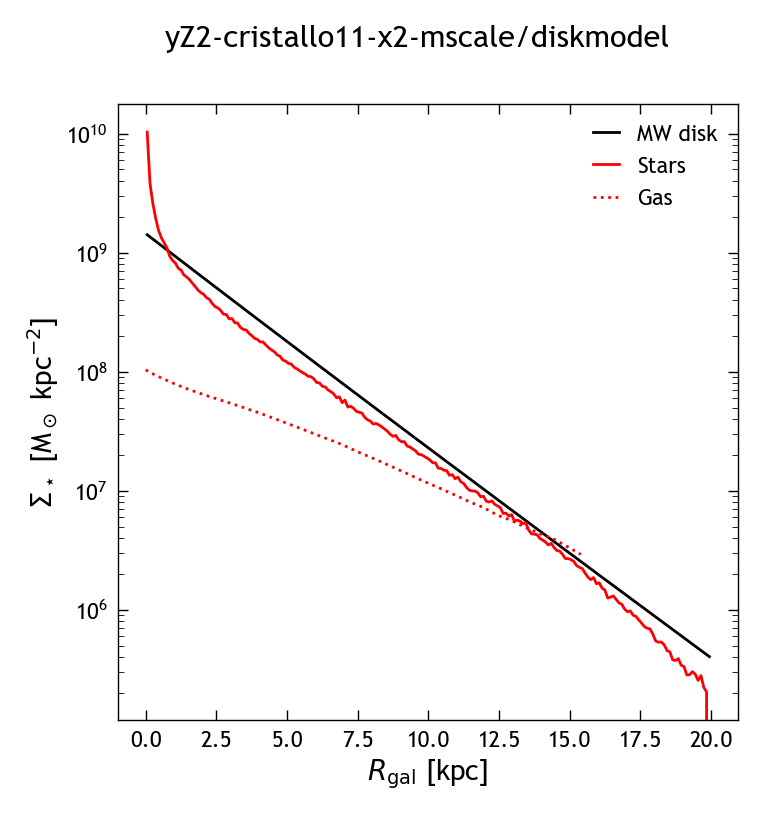

In [368]:
# Plot the stellar density gradient
from multizone.src.models import two_component_disk

fig, ax = plt.subplots()

rbins = np.arange(0, 20+ZONE_WIDTH, ZONE_WIDTH)
rbin_centers = get_bin_centers(rbins)

# Analytic model
mw_disk = two_component_disk()
total_disk = np.array([mw_disk(r) for r in rbin_centers])
ax.plot(rbin_centers, total_disk, 'k-', label='MW disk')

# Multi-zone output
densities = stellar_density_gradient(mzs, rbins, origin=False)
ax.plot(rbin_centers, densities, 'r-', label='Stars')

# Gas density
sigma_gas, radii = gas_density_gradient(mzs.name)
ax.plot(radii, sigma_gas, 'r:', label='Gas')

ax.set_xlabel(r'$R_{\rm gal}$ [kpc]')
ax.set_ylabel(r'$\Sigma_\star$ [M$_\odot$ kpc$^{-2}$]')
ax.set_yscale('log')
ax.legend(loc='upper right', frameon=False)
fig.suptitle(OUTPUT_NAME)
fig.savefig(output_dir / 'density_gradient.png')
plt.show()

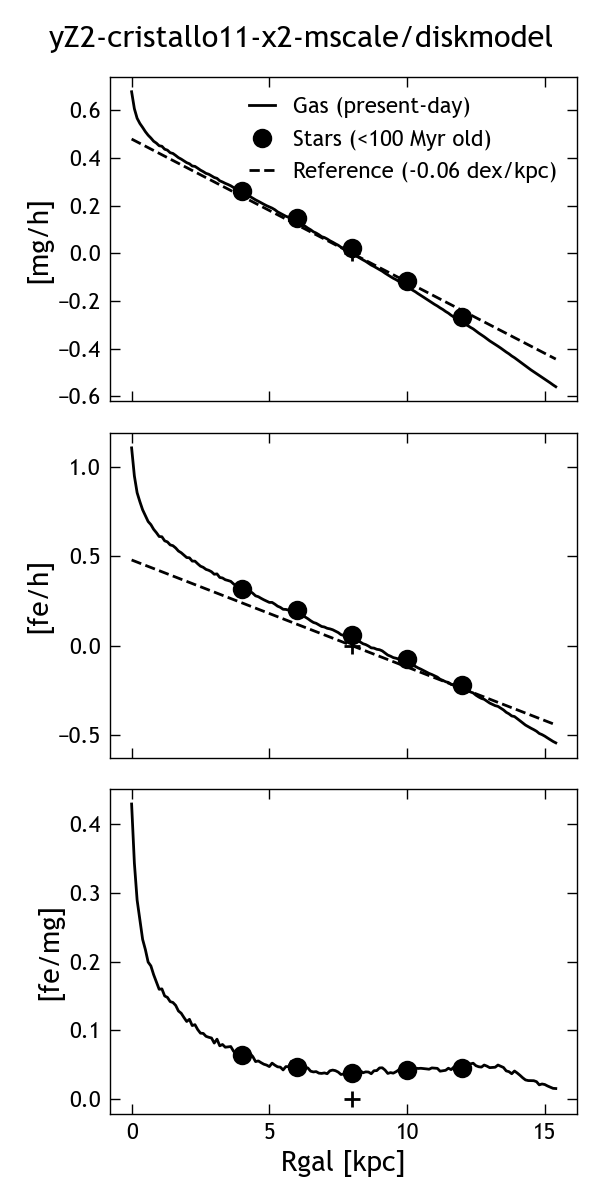

In [369]:
# Plot abundance gradients
abundances = ['[mg/h]', '[fe/h]', '[fe/mg]']
fig, axs = plt.subplots(
    len(abundances), 1, 
    figsize=(3, 6),
    tight_layout=True, 
    sharex=True
)

# Gas
mout = vice.output(str(paths.multizone / mzs.name))
xarr = np.arange(0, MAX_SF_RADIUS, ZONE_WIDTH)
for i, abund in enumerate(abundances):
    axs[i].plot(xarr, radial_gradient(mout, abund), 'k-', label='Gas (present-day)')
    axs[i].set_ylabel(abund)
# Stars
median_abundances = np.zeros((len(abundances), len(GALR_BINS)-1))
for j in range(len(GALR_BINS)-1):
    galr_lim = GALR_BINS[j:j+2]
    subset = mzs.filter({
        'galr_final': tuple(galr_lim), 
        'zfinal': (0, 0.5),
        'age': (0, 0.1)
    })
    median_abundances[:,j] = [
        weighted_quantile(subset.stars, a, 'mstar', quantile=0.5) for a in abundances
    ]
for i, abund in enumerate(abundances):  
    axs[i].plot(get_bin_centers(GALR_BINS), median_abundances[i], 'ko', label='Stars (<100 Myr old)')
# Reference gradient and sun
axs[0].plot(xarr, -0.06 * (xarr - 8.0), 'k--', label='Reference (-0.06 dex/kpc)')
axs[0].scatter([8], [0], marker='+', color='k')
axs[1].plot(xarr, -0.06 * (xarr - 8.0), 'k--', label='Reference (-0.06 dex/kpc)')
axs[1].scatter([8], [0], marker='+', color='k')
axs[2].scatter([8], [0], marker='+', color='k')
axs[0].legend()
axs[-1].set_xlabel('Rgal [kpc]')
fig.suptitle(OUTPUT_NAME)
fig.savefig(output_dir / 'abundance_gradients.png')
plt.show()

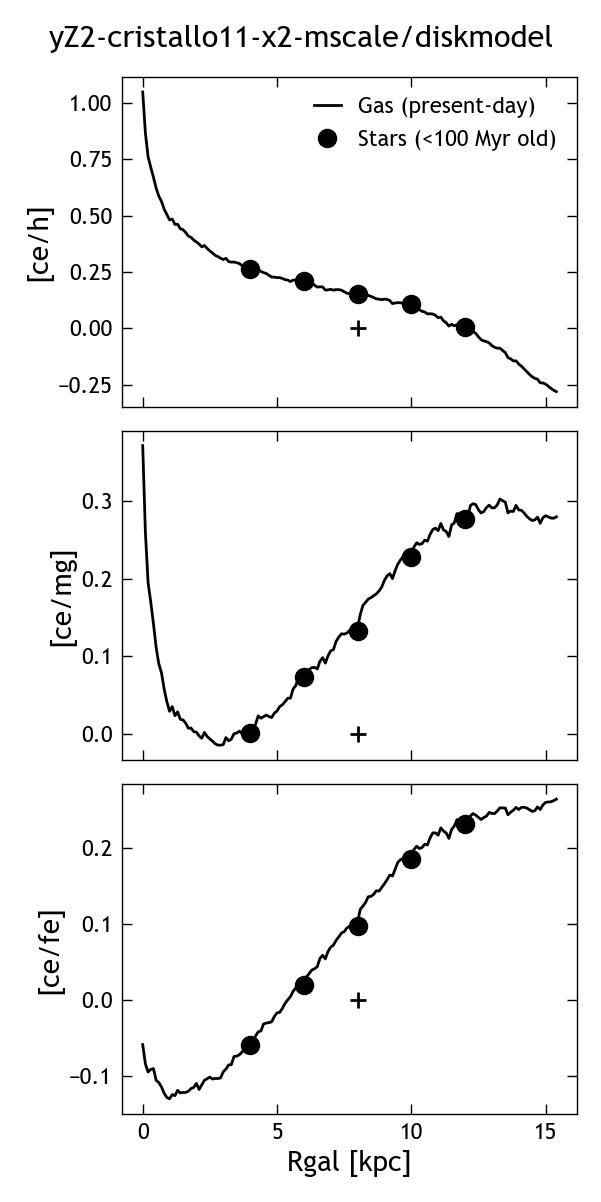

In [370]:
# Plot Ce abundance gradients
abundances = ['[ce/h]', '[ce/mg]', '[ce/fe]']
fig, axs = plt.subplots(
    len(abundances), 1, 
    figsize=(3, 6),
    tight_layout=True, 
    sharex=True
)

# Gas
mout = vice.output(str(paths.multizone / mzs.name))
xarr = np.arange(0, MAX_SF_RADIUS, ZONE_WIDTH)
for i, abund in enumerate(abundances):
    axs[i].plot(xarr, radial_gradient(mout, abund), 'k-', label='Gas (present-day)')
    axs[i].set_ylabel(abund)
# Stars
median_abundances = np.zeros((len(abundances), len(GALR_BINS)-1))
for j in range(len(GALR_BINS)-1):
    galr_lim = GALR_BINS[j:j+2]
    subset = mzs.filter({
        'galr_final': tuple(galr_lim), 
        'zfinal': (0, 0.5),
        'age': (0, 0.1)
    })
    median_abundances[:,j] = [
        weighted_quantile(subset.stars, a, 'mstar', quantile=0.5) for a in abundances
    ]
for i, abund in enumerate(abundances):  
    axs[i].plot(get_bin_centers(GALR_BINS), median_abundances[i], 'ko', label='Stars (<100 Myr old)')
# Reference gradient and sun
axs[0].scatter([8], [0], marker='+', color='k')
axs[1].scatter([8], [0], marker='+', color='k')
axs[2].scatter([8], [0], marker='+', color='k')
axs[0].legend()
axs[-1].set_xlabel('Rgal [kpc]')
fig.suptitle(OUTPUT_NAME)
fig.savefig(output_dir / 'ce_gradients.png')
plt.show()